# Predicción multihorizonte de la potencia de un molino de bolas mediante ARIMAX

**Trabajo Fin de Máster — Máster Universitario en Big Data y Ciencia de Datos**  
**Autor:** Jordan Gómez Espinoza  
**Modelo:** ARIMAX estimado mediante la representación de espacio de estados SARIMAX  
**Versión del experimento:** 1.1 — horizonte completamente parametrizable

Este notebook desarrolla un modelo estadístico interpretable para pronosticar la trayectoria de potencia activa (`POT`) durante el horizonte definido en la configuración única. La duración, el número de trayectorias, las validaciones, los nombres de los artefactos y el resumen final se derivan automáticamente de `HORIZON`, `MODEL_FREQ` y `ROLLING_STRIDE`.

Incorpora la dinámica autorregresiva de la potencia y cuatro variables exógenas históricas: `F80`, `T`, `AA` y `AD`.

> **Confidencialidad.** El análisis identifica el equipo únicamente como molino de bolas 1D. El archivo industrial no debe publicarse; el código, la configuración y los resultados agregados sí pueden incorporarse al TFM.


## Contrato experimental común

| Elemento | Decisión metodológica |
|---|---|
| Datos originales | 444.580 mediciones reales cada 5 s |
| Agregación | Media de tres mediciones reales por intervalo completo de 15 s |
| Dataset final | 148.193 observaciones completas, sin imputar el objetivo |
| Objetivo | `POT` (MW) |
| Exógenas | `F80`, `T`, `AA`, `AD` |
| Contexto operacional | Definido mediante `WINDOW` y `MODEL_FREQ` |
| Horizonte | Definido mediante `HORIZON` y `MODEL_FREQ` |
| División | 113.633 observaciones de entrenamiento, 17.280 de validación (3 días) y 17.280 de prueba (3 días) |
| Evaluación | *Rolling origin* con avance definido por `ROLLING_STRIDE` |
| Referencia | Persistencia del último valor de `POT` observado |

ARIMAX no necesita una matriz fija de retardos: su memoria efectiva queda determinada por el orden `(p,d,q)` y por el estado filtrado. Los parámetros se estiman exclusivamente con entrenamiento. Durante validación y prueba se actualiza el estado con observaciones ya ocurridas, pero no se reestiman parámetros.


## Supuesto sobre las variables exógenas futuras

Para pronosticar con ARIMAX es necesario aportar valores exógenos durante todo el horizonte configurado. Usar los valores reales futuros de `F80`, `T`, `AA` y `AD` constituiría fuga de información. Por ello se adopta un supuesto operacional reproducible:

\[
\hat{\mathbf{x}}_{t+h\mid t}=\mathbf{x}_{t-1},\qquad h=0,\ldots,H-1,
\]

donde \(H\) corresponde a `HORIZON`. Cada covariable permanece constante en su último valor observado durante la trayectoria. Esta decisión se registra en los artefactos y debe explicarse al comparar ARIMAX con TFT y XGBoost.


## 1. Entorno de ejecución

El modelo se implementa con `statsmodels`. Para preparar un entorno limpio puede ejecutarse una sola vez, antes de la corrida oficial:

```bash
pip install "statsmodels>=0.14,<0.16" pandas numpy scikit-learn matplotlib seaborn joblib
```

Después se reinicia el kernel y se ejecuta **Run All**. ARIMAX trabaja en CPU y puede tardar varios minutos durante la búsqueda del orden y el ajuste final.


In [1]:
# ============================================================
# 1. IMPORTACIONES GENERALES Y CONFIGURACIÓN VISUAL
# ============================================================

import hashlib
import json
import os
import platform
import random
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5), "figure.dpi": 120, "savefig.dpi": 300,
    "axes.titlesize": 13, "axes.labelsize": 11, "legend.fontsize": 9,
})


In [2]:
from pathlib import Path
import hashlib
import pandas as pd

archivo = Path("1D_POT_2.csv")
raw = pd.read_csv(archivo, sep=",")

fechas = pd.to_datetime(
    raw["FECHA"],
    dayfirst=True,
    errors="raise"
)

conteos_15s = (
    raw.assign(FECHA=fechas)
       .set_index("FECHA")["POT"]
       .resample("15s")
       .count()
)

print("Filas crudas:", len(raw))
print("Fecha inicial:", fechas.min())
print("Fecha final:", fechas.max())
print("Duplicados:", fechas.duplicated().sum())
print("Saltos distintos de 5 s:", (fechas.diff().dropna() != pd.Timedelta(seconds=5)).sum())
print("Intervalos completos de 15 s:", int((conteos_15s == 3).sum()))
print("SHA-256:", hashlib.sha256(archivo.read_bytes()).hexdigest())

Filas crudas: 444580
Fecha inicial: 2026-08-01 14:45:00
Fecha final: 2026-08-27 08:13:15
Duplicados: 0
Saltos distintos de 5 s: 0
Intervalos completos de 15 s: 148193
SHA-256: 13ab2cc37de733a14a352a7cd8c7b1b681499e4b8470d360205a5e75b84a7cf1


In [3]:
# ============================================================
# 2. CONFIGURACIÓN ÚNICA DEL EXPERIMENTO
# ============================================================

DATE_COL = "FECHA"
TARGET = "POT"
EXOG_COLS = ["F80", "T", "AA", "AD"]
NUMERIC_COLS = EXOG_COLS + [TARGET]
REQUIRED_COLS = [DATE_COL] + EXOG_COLS + [TARGET]

CSV_FILENAME = "1D_POT_2.csv"
CSV_SEPARATOR = ","
DATE_FORMAT = "%d/%m/%Y %H:%M:%S"
RAW_FREQ = "5s"
MODEL_FREQ = "15s"
RAW_POINTS_PER_MODEL_BIN = 3

WINDOW = 120                  # 120 × 15 s = 30 min
HORIZON = 60                  # 60 × 15 s = 15 min; puede modificarse aquí
ROLLING_STRIDE = HORIZON      # trayectorias no solapadas
VAL_DAYS = 3
TEST_DAYS = 3

ARIMAX_ORDER = None           # None activa selección automática
P_VALUES = [0, 1, 2, 3]
Q_VALUES = [0, 1, 2]
ADF_SIGNIFICANCE = 0.05
ORDER_SELECTION_DAYS = 3
MAXITER_SELECTION = 80
MAXITER_FINAL = 150
FIT_METHOD = "lbfgs"
SEASONAL_ORDER = (0, 0, 0, 0)
TREND = "c"

EXOG_FUTURE_STRATEGY = "last_observation_carried_forward_per_forecast_origin"
INTERVAL_ALPHA = 0.20         # intervalo central aproximado P10-P90
BOOTSTRAP_REPETITIONS = 2_000
POWER_DANGER_THRESHOLD = 2.28
SEED = 42

EXPECTED_RAW_ROWS = 444_580
EXPECTED_MODEL_ROWS = 148_193
EXPECTED_SHA256 = ("13ab2cc37de733a14a352a7cd8c7b1b681499e4b8470d360205a5e75b84a7cf1")
STRICT_DATASET_VALIDATION = True

# Magnitudes derivadas: no deben escribirse manualmente en otras celdas.
MODEL_STEP_SECONDS = float(pd.Timedelta(MODEL_FREQ).total_seconds())
WINDOW_MINUTES = WINDOW * MODEL_STEP_SECONDS / 60.0
HORIZON_MINUTES = HORIZON * MODEL_STEP_SECONDS / 60.0
ROLLING_STRIDE_MINUTES = ROLLING_STRIDE * MODEL_STEP_SECONDS / 60.0
HORIZON_LABEL = f"{HORIZON_MINUTES:g}"
HORIZON_TAG = HORIZON_LABEL.replace(".", "p") + "min"

assert WINDOW > 0
assert HORIZON > 0
assert ROLLING_STRIDE > 0
assert HORIZON <= EXPECTED_MODEL_ROWS
assert INTERVAL_ALPHA > 0 and INTERVAL_ALPHA < 1

ARTIFACT_DIR = Path(f"resultados_arimax_{HORIZON_TAG}_final")
MODEL_DIR = ARTIFACT_DIR / "modelo"
FIGURE_DIR = ARTIFACT_DIR / "figuras"
TABLE_DIR = ARTIFACT_DIR / "tablas"
for folder in (ARTIFACT_DIR, MODEL_DIR, FIGURE_DIR, TABLE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Contexto común: {WINDOW} pasos = {WINDOW_MINUTES:g} min")
print(f"Horizonte: {HORIZON} pasos = {HORIZON_MINUTES:g} min")
print(f"Avance rolling: {ROLLING_STRIDE} pasos = {ROLLING_STRIDE_MINUTES:g} min")
print("Exógenas futuras: persistencia del último valor observado")
print(f"Artefactos: {ARTIFACT_DIR.resolve()}")


Contexto común: 120 pasos = 30 min
Horizonte: 60 pasos = 15 min
Avance rolling: 60 pasos = 15 min
Exógenas futuras: persistencia del último valor observado
Artefactos: C:\Users\jgomeze\Documents\woody\Py\resultados_arimax_15min_final


## 2. Ingesta, auditoría y agregación temporal

Se comprueba la identidad del archivo mediante SHA-256, su esquema, cronología, frecuencia y valores no finitos. La agregación mantiene solo intervalos con tres observaciones reales. No se utiliza relleno, interpolación ni eliminación automática de duplicados.


In [4]:
# ============================================================
# 3. LOCALIZACIÓN E IDENTIDAD DEL ARCHIVO
# ============================================================

def localizar_csv(filename):
    candidates = [
        Path(filename), Path.cwd() / filename, Path("/content") / filename,
        Path("/kaggle/working") / filename, Path("upload") / filename,
        Path("../upload") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f"No se encontró {filename}. Colóquelo junto al notebook.")

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

CSV_PATH = localizar_csv(CSV_FILENAME)
DATASET_SHA256 = sha256_file(CSV_PATH)
print("CSV:", CSV_PATH)
print("SHA-256:", DATASET_SHA256)
if STRICT_DATASET_VALIDATION:
    assert DATASET_SHA256 == EXPECTED_SHA256, "El archivo no coincide con el dataset auditado."


CSV: C:\Users\jgomeze\Documents\woody\Py\1D_POT_2.csv
SHA-256: 13ab2cc37de733a14a352a7cd8c7b1b681499e4b8470d360205a5e75b84a7cf1


In [5]:
# ============================================================
# 4. LECTURA Y AUDITORÍA DEL CSV CRUDO
# ============================================================

raw = pd.read_csv(CSV_PATH, sep=CSV_SEPARATOR)
assert list(raw.columns) == REQUIRED_COLS, f"Columnas inesperadas: {list(raw.columns)}"
assert len(raw) == EXPECTED_RAW_ROWS, f"Filas crudas: {len(raw):,}"

raw[DATE_COL] = pd.to_datetime(raw[DATE_COL], format=DATE_FORMAT, errors="coerce")
assert raw[DATE_COL].notna().all(), "Existen fechas no interpretables."
for column in NUMERIC_COLS:
    raw[column] = pd.to_numeric(raw[column], errors="coerce")

audit_raw = pd.DataFrame({
    "dtype": raw.dtypes.astype(str), "nulos": raw.isna().sum(),
    "unicos": raw.nunique(dropna=True),
})
display(audit_raw)
assert raw[NUMERIC_COLS].notna().all().all()
assert np.isfinite(raw[NUMERIC_COLS].to_numpy(dtype=float)).all()
assert raw[DATE_COL].is_monotonic_increasing
assert not raw[DATE_COL].duplicated().any()

raw_deltas = raw[DATE_COL].diff().dropna()
display(raw_deltas.value_counts().rename_axis("delta").to_frame("conteo").head(10))
assert raw_deltas.eq(pd.Timedelta(RAW_FREQ)).all(), "La frecuencia cruda no es exactamente 5 s."
print(f"Periodo crudo: {raw[DATE_COL].min()} — {raw[DATE_COL].max()}")
print(f"Filas crudas: {len(raw):,}")
display(raw[NUMERIC_COLS].describe().T)


,dtype,nulos,unicos
FECHA,datetime64[ns],0,444580
F80,float64,0,337745
T,float64,0,341555
AA,float64,0,412111
AD,float64,0,420420
POT,float64,0,280012


,conteo
delta,
0 days 00:00:05,444579


Periodo crudo: 2026-08-01 14:45:00 — 2026-08-27 08:13:15
Filas crudas: 444,580


,count,mean,std,min,25%,50%,75%,max
F80,"444,580.000000","6,818.917272",879.605916,0.000000,"6,467.866699","6,744.128662","7,074.821533","10,382.029300"
T,"444,580.000000",272.198056,19.631657,0.205997,262.432564,276.286972,284.679634,313.106445
AA,"444,580.000000","2,297.236965",355.756651,746.734558,"2,031.433075","2,310.303833","2,529.837219","3,742.961914"
AD,"444,580.000000","5,048.962904",636.610770,"3,309.231934","4,572.738038","4,958.445068","5,599.362183","6,776.545898"
POT,"444,580.000000",2.312818,0.030195,2.229558,2.288449,2.307366,2.336656,2.443580


In [6]:
# ============================================================
# 5. AGREGACIÓN 5 s -> 15 s SIN IMPUTACIÓN
# ============================================================

raw_ts = raw.set_index(DATE_COL)[NUMERIC_COLS].sort_index()
grouped = raw_ts.resample(MODEL_FREQ, origin=raw_ts.index[0])
bin_counts = grouped.count()
bin_means = grouped.mean()
complete_mask = bin_counts.eq(RAW_POINTS_PER_MODEL_BIN).all(axis=1)
incomplete_bins = bin_counts.loc[~complete_mask]
print(f"Intervalos incompletos excluidos: {len(incomplete_bins):,}")
if len(incomplete_bins):
    display(incomplete_bins)

df = bin_means.loc[complete_mask].copy()
df.index.name = DATE_COL
assert len(df) == EXPECTED_MODEL_ROWS
assert df.index.is_monotonic_increasing and df.index.is_unique
assert df.index.to_series().diff().dropna().eq(pd.Timedelta(MODEL_FREQ)).all()
assert df[NUMERIC_COLS].notna().all().all()
assert np.isfinite(df[NUMERIC_COLS].to_numpy(dtype=float)).all()

dataset_audit = {
    "csv_path": str(CSV_PATH), "sha256": DATASET_SHA256,
    "raw_rows": int(len(raw)), "model_rows": int(len(df)),
    "incomplete_bins_excluded": int((~complete_mask).sum()),
    "start": str(df.index.min()), "end": str(df.index.max()),
    "raw_frequency": RAW_FREQ, "model_frequency": MODEL_FREQ,
    "imputation": "none",
}
print(json.dumps(dataset_audit, indent=2, ensure_ascii=False))
display(df.head())


Intervalos incompletos excluidos: 1


,F80,T,AA,AD,POT
FECHA,,,,,
2026-08-27 08:13:15,1,1,1,1,1


{
  "csv_path": "C:\\Users\\jgomeze\\Documents\\woody\\Py\\1D_POT_2.csv",
  "sha256": "13ab2cc37de733a14a352a7cd8c7b1b681499e4b8470d360205a5e75b84a7cf1",
  "raw_rows": 444580,
  "model_rows": 148193,
  "incomplete_bins_excluded": 1,
  "start": "2026-08-01 14:45:00",
  "end": "2026-08-27 08:13:00",
  "raw_frequency": "5s",
  "model_frequency": "15s",
  "imputation": "none"
}


,F80,T,AA,AD,POT
FECHA,,,,,
2026-08-01 14:45:00,"5,937.019857",259.124044,"2,182.784993","5,957.765137",2.364779
2026-08-01 14:45:15,"5,934.916504",258.904917,"2,183.043701","5,907.456706",2.364624
2026-08-01 14:45:30,"5,932.813314",258.674642,"2,183.302490","5,908.003907",2.364469
2026-08-01 14:45:45,"5,930.709961",258.435557,"2,183.561279","5,896.214355",2.364313
2026-08-01 14:46:00,"5,928.606608",258.196462,"2,183.819987","5,907.605794",2.364158


,min,max,mean,std,n_negative
F80,0.000001,"10,382.029300","6,818.918611",879.575286,0
T,0.205997,312.996562,272.198056,19.628678,0
AA,749.931763,"3,314.998779","2,297.235466",355.688533,0
AD,"3,330.113525","6,744.123047","5,048.966270",635.486513,0
POT,2.229676,2.443293,2.312818,0.030194,0


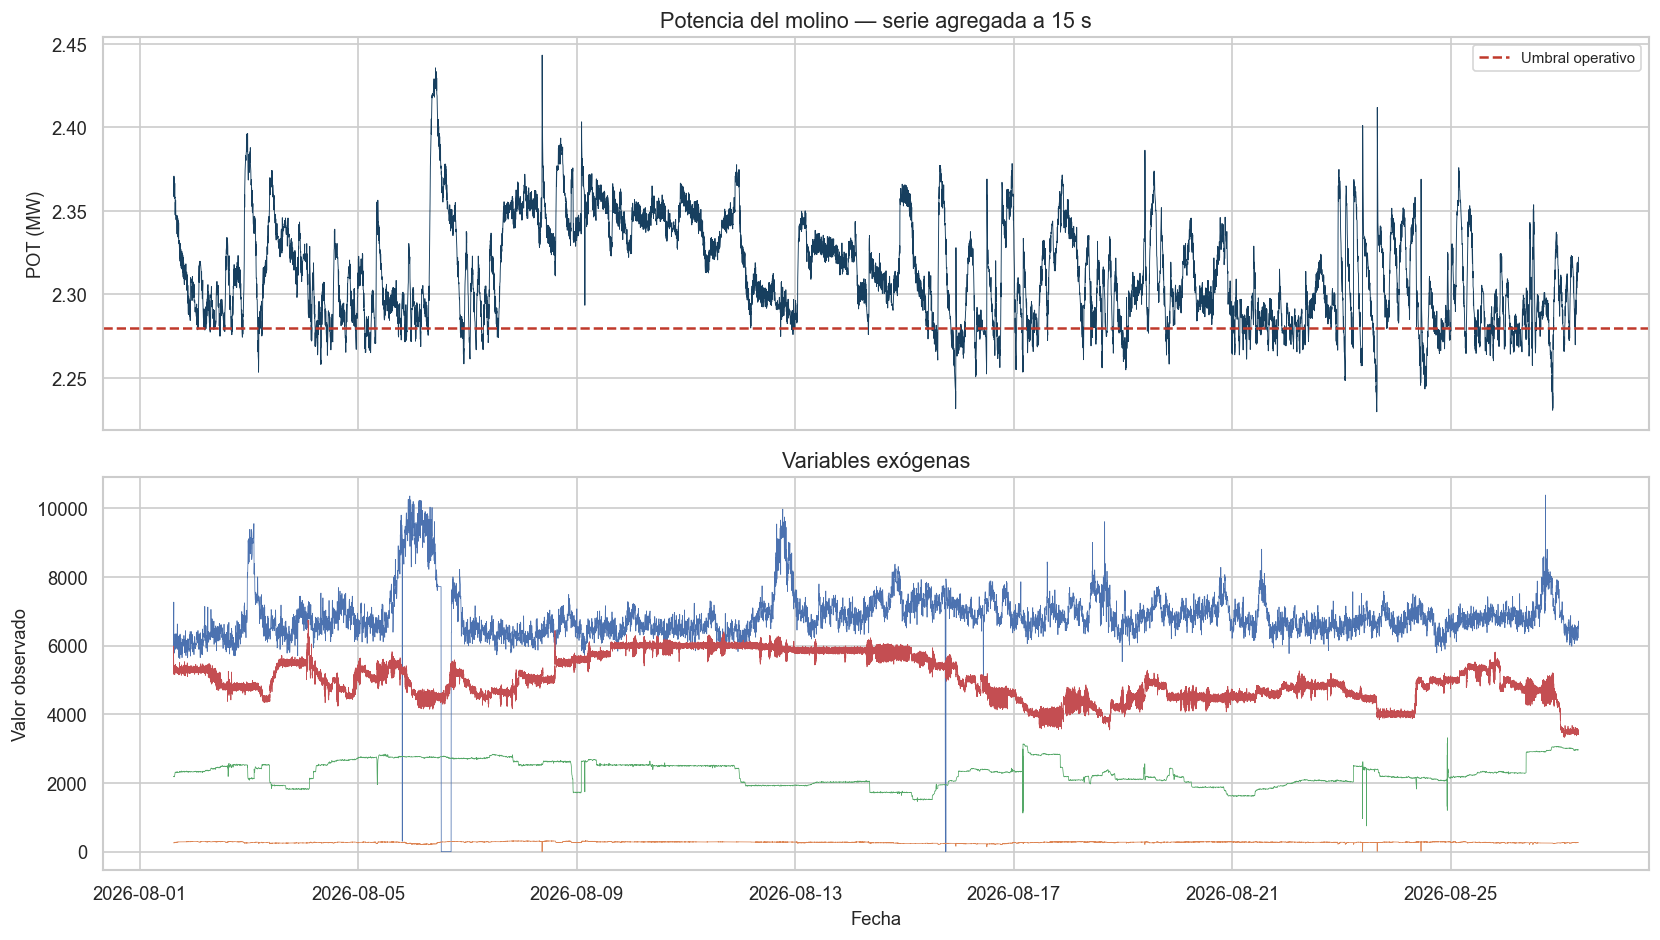

In [7]:
# ============================================================
# 6. CONTROL DE RANGOS Y VISUALIZACIÓN DESCRIPTIVA
# ============================================================

physical_checks = pd.DataFrame({
    "min": df[NUMERIC_COLS].min(), "max": df[NUMERIC_COLS].max(),
    "mean": df[NUMERIC_COLS].mean(), "std": df[NUMERIC_COLS].std(),
    "n_negative": (df[NUMERIC_COLS] < 0).sum(),
})
display(physical_checks)
assert (df[NUMERIC_COLS] >= 0).all().all(), "Se detectaron valores negativos; revisar con planta."

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df.index, df[TARGET], linewidth=0.55, color="#173F5F")
axes[0].axhline(POWER_DANGER_THRESHOLD, color="#C0392B", linestyle="--", label="Umbral operativo")
axes[0].set(ylabel="POT (MW)", title="Potencia del molino — serie agregada a 15 s")
axes[0].legend()
axes[1].plot(df.index, df[EXOG_COLS], linewidth=0.45)
axes[1].set(ylabel="Valor observado", xlabel="Fecha", title="Variables exógenas")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_series_temporales.png", bbox_inches="tight")
plt.show()


## 3. División temporal y escalamiento

El escalador de variables exógenas se ajusta exclusivamente con entrenamiento. `POT` permanece en MW para que coeficientes, residuos e intervalos se interpreten en la unidad física original.


In [8]:
# ============================================================
# 7. DIVISIÓN CRONOLÓGICA Y ORÍGENES DINÁMICOS
# ============================================================

steps_per_day = int(pd.Timedelta(days=1) / pd.Timedelta(MODEL_FREQ))
VAL_LEN = VAL_DAYS * steps_per_day
TEST_LEN = TEST_DAYS * steps_per_day
TOTAL_LEN = len(df)
TRAIN_LEN = TOTAL_LEN - VAL_LEN - TEST_LEN

assert TRAIN_LEN > WINDOW + HORIZON
assert VAL_LEN >= HORIZON
assert TEST_LEN >= HORIZON
assert TRAIN_LEN + VAL_LEN + TEST_LEN == TOTAL_LEN

VAL_START, VAL_END = TRAIN_LEN, TRAIN_LEN + VAL_LEN
TEST_START, TEST_END = VAL_END, TOTAL_LEN

train_df = df.iloc[:TRAIN_LEN].copy()
val_df = df.iloc[VAL_START:VAL_END].copy()
test_df = df.iloc[TEST_START:TEST_END].copy()
split_table = pd.DataFrame([
    {"particion": "train", "filas": len(train_df), "inicio": train_df.index.min(), "fin": train_df.index.max()},
    {"particion": "validation", "filas": len(val_df), "inicio": val_df.index.min(), "fin": val_df.index.max()},
    {"particion": "test", "filas": len(test_df), "inicio": test_df.index.min(), "fin": test_df.index.max()},
])
display(split_table)
assert train_df.index.max() < val_df.index.min() < test_df.index.min()

def construir_origenes(start_position, end_position):
    return np.arange(
        start_position,
        end_position - HORIZON + 1,
        ROLLING_STRIDE,
        dtype=np.int64,
    )

def numero_esperado_origenes(start_position, end_position):
    available = end_position - start_position
    if available < HORIZON:
        return 0
    return ((available - HORIZON) // ROLLING_STRIDE) + 1

val_origins = construir_origenes(VAL_START, VAL_END)
test_origins = construir_origenes(TEST_START, TEST_END)

expected_val_origins = numero_esperado_origenes(VAL_START, VAL_END)
expected_test_origins = numero_esperado_origenes(TEST_START, TEST_END)

assert len(val_origins) == expected_val_origins > 0
assert len(test_origins) == expected_test_origins > 0

val_evaluated_points = len(val_origins) * HORIZON
test_evaluated_points = len(test_origins) * HORIZON

origin_summary = pd.DataFrame([
    {
        "particion": "validation",
        "origenes": len(val_origins),
        "pasos_por_trayectoria": HORIZON,
        "puntos_evaluados": val_evaluated_points,
        "cobertura_particion_pct": 100 * val_evaluated_points / VAL_LEN,
    },
    {
        "particion": "test",
        "origenes": len(test_origins),
        "pasos_por_trayectoria": HORIZON,
        "puntos_evaluados": test_evaluated_points,
        "cobertura_particion_pct": 100 * test_evaluated_points / TEST_LEN,
    },
])
display(origin_summary)

print(f"Orígenes de validación: {len(val_origins)}")
print(f"Orígenes de prueba: {len(test_origins)}")


,particion,filas,inicio,fin
0,train,113633,2026-08-01 14:45:00,2026-08-21 08:13:00
1,validation,17280,2026-08-21 08:13:15,2026-08-24 08:13:00
2,test,17280,2026-08-24 08:13:15,2026-08-27 08:13:00


,particion,origenes,pasos_por_trayectoria,puntos_evaluados,cobertura_particion_pct
0,validation,288,60,17280,100.000000
1,test,288,60,17280,100.000000


Orígenes de validación: 288
Orígenes de prueba: 288


In [9]:
# ============================================================
# 8. ESCALAMIENTO SIN FUGA Y AUDITORÍA DE ORÍGENES
# ============================================================

scaler_exog = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler_exog.fit_transform(train_df[EXOG_COLS]), index=train_df.index, columns=EXOG_COLS
)
X_val_scaled = pd.DataFrame(
    scaler_exog.transform(val_df[EXOG_COLS]), index=val_df.index, columns=EXOG_COLS
)
X_test_scaled = pd.DataFrame(
    scaler_exog.transform(test_df[EXOG_COLS]), index=test_df.index, columns=EXOG_COLS
)
X_all_scaled = pd.concat([X_train_scaled, X_val_scaled, X_test_scaled])
y_train = train_df[TARGET].astype(float)
y_all = df[TARGET].astype(float)

assert X_all_scaled.index.equals(df.index)
assert np.isfinite(X_all_scaled.to_numpy()).all()
leakage_audit = pd.DataFrame([
    {
        "particion": name, "primer_origen": df.index[origins[0]],
        "ultima_observacion_disponible": df.index[origins[0] - 1],
        "ultimo_objetivo": df.index[origins[-1] + HORIZON - 1],
        "n_origenes": len(origins),
    }
    for name, origins in (("validation", val_origins), ("test", test_origins))
])
display(leakage_audit)
assert val_origins[-1] + HORIZON - 1 < VAL_END
assert test_origins[-1] + HORIZON - 1 < TEST_END


,particion,primer_origen,ultima_observacion_disponible,ultimo_objetivo,n_origenes
0,validation,2026-08-21 08:13:15,2026-08-21 08:13:00,2026-08-24 08:13:00,288
1,test,2026-08-24 08:13:15,2026-08-24 08:13:00,2026-08-27 08:13:00,288


## 4. Estacionariedad y selección del orden

Se considera el modelo

\[
\Phi_p(B)(1-B)^d y_t=c+\boldsymbol{\beta}^{\top}\mathbf{x}_t+\Theta_q(B)\varepsilon_t.
\]

`d` se determina mediante la prueba ADF sobre un bloque continuo del entrenamiento. Los órdenes candidatos se comparan mediante AIC usando los últimos tres días de entrenamiento; solo los ajustes convergentes pueden ser seleccionados. Esta búsqueda no consulta validación ni prueba.


In [10]:
# ============================================================
# 9. IMPORTACIÓN DE STATSMODELS Y VERSIONES
# ============================================================

import statsmodels
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

print("Python:", sys.version.split()[0])
print("statsmodels:", statsmodels.__version__)
assert tuple(int(part) for part in statsmodels.__version__.split(".")[:2]) >= (0, 13), "Actualice statsmodels."


Python: 3.8.20
statsmodels: 0.14.1


In [11]:
# ============================================================
# 10. PRUEBA ADF Y ORDEN DE DIFERENCIACIÓN
# ============================================================

def ejecutar_adf(series, max_observations=30_000):
    values = pd.Series(series).dropna().astype(float)
    if len(values) > max_observations:
        values = values.iloc[-max_observations:]
    result = adfuller(values.to_numpy(), autolag="AIC")
    return {
        "ADF_STATISTIC": float(result[0]), "P_VALUE": float(result[1]),
        "USED_LAG": int(result[2]), "N_OBS": int(result[3]),
        "CRITICAL_1_pct": float(result[4]["1%"]),
        "CRITICAL_5_pct": float(result[4]["5%"]),
        "CRITICAL_10_pct": float(result[4]["10%"]),
    }

adf_level = ejecutar_adf(y_train)
if adf_level["P_VALUE"] <= ADF_SIGNIFICANCE:
    D_ORDER = 0
    adf_difference = None
else:
    D_ORDER = 1
    adf_difference = ejecutar_adf(y_train.diff().dropna())

adf_table = pd.DataFrame([
    {"serie": "nivel", **adf_level},
    *([{"serie": "primera_diferencia", **adf_difference}] if adf_difference else []),
])
display(adf_table)
print("Orden de diferenciación seleccionado: d =", D_ORDER)


,serie,ADF_STATISTIC,P_VALUE,USED_LAG,N_OBS,CRITICAL_1_pct,CRITICAL_5_pct,CRITICAL_10_pct
0,nivel,-4.927335,0.000031,21,29978,-3.430568,-2.861636,-2.566821


Orden de diferenciación seleccionado: d = 0


In [12]:
# ============================================================
# 11. BÚSQUEDA DEL ORDEN ARIMAX POR AIC
# ============================================================

def seleccionar_orden_arimax(y_input, X_input, d_order):
    selection_len = min(ORDER_SELECTION_DAYS * steps_per_day, len(y_input))
    y_selection = y_input.iloc[-selection_len:].copy()
    X_selection = X_input.iloc[-selection_len:].copy()
    rows = []

    for p in P_VALUES:
        for q in Q_VALUES:
            order = (p, d_order, q)
            print(f"Probando ARIMAX{order}...")
            captured = []
            try:
                with warnings.catch_warnings(record=True) as caught:
                    warnings.simplefilter("always")
                    candidate = SARIMAX(
                        endog=y_selection, exog=X_selection, order=order,
                        seasonal_order=SEASONAL_ORDER, trend=TREND,
                        enforce_stationarity=False, enforce_invertibility=False,
                        simple_differencing=False, concentrate_scale=False,
                        missing="raise",
                    ).fit(disp=False, maxiter=MAXITER_SELECTION, method=FIT_METHOD)
                captured = [str(item.message) for item in caught]
                converged = bool(candidate.mle_retvals.get("converged", True))
                rows.append({
                    "p": p, "d": d_order, "q": q,
                    "AIC": float(candidate.aic), "BIC": float(candidate.bic),
                    "CONVERGED": converged, "N_WARNINGS": len(captured),
                    "WARNINGS": " | ".join(captured), "ERROR": "",
                })
                print(f"AIC={candidate.aic:.3f} | BIC={candidate.bic:.3f} | convergió={converged}")
            except Exception as error:
                rows.append({
                    "p": p, "d": d_order, "q": q, "AIC": np.nan, "BIC": np.nan,
                    "CONVERGED": False, "N_WARNINGS": len(captured),
                    "WARNINGS": " | ".join(captured), "ERROR": repr(error),
                })
                print("Error:", repr(error))

    table = pd.DataFrame(rows).sort_values("AIC", na_position="last").reset_index(drop=True)
    eligible = table.loc[table["CONVERGED"] & np.isfinite(table["AIC"])]
    if eligible.empty:
        raise RuntimeError("Ningún modelo candidato convergió. Revise la tabla de selección.")
    best = eligible.iloc[0]
    selected = (int(best["p"]), int(best["d"]), int(best["q"]))
    return selected, table

if ARIMAX_ORDER is None:
    SELECTED_ORDER, order_selection = seleccionar_orden_arimax(y_train, X_train_scaled, D_ORDER)
else:
    SELECTED_ORDER = tuple(ARIMAX_ORDER)
    order_selection = pd.DataFrame([{"manual_order": str(SELECTED_ORDER)}])

print("Orden seleccionado:", SELECTED_ORDER)
display(order_selection)


Probando ARIMAX(0, 0, 0)...
AIC=-87499.748 | BIC=-87453.204 | convergió=True
Probando ARIMAX(0, 0, 1)...
AIC=-109776.583 | BIC=-109722.282 | convergió=True
Probando ARIMAX(0, 0, 2)...
AIC=-128731.435 | BIC=-128669.378 | convergió=False
Probando ARIMAX(1, 0, 0)...
AIC=-190073.266 | BIC=-190018.965 | convergió=False
Probando ARIMAX(1, 0, 1)...
AIC=-190195.300 | BIC=-190133.242 | convergió=False
Probando ARIMAX(1, 0, 2)...
AIC=-192336.261 | BIC=-192266.446 | convergió=False
Probando ARIMAX(2, 0, 0)...
AIC=-190610.034 | BIC=-190547.977 | convergió=False
Probando ARIMAX(2, 0, 1)...
AIC=-192595.465 | BIC=-192525.650 | convergió=False
Probando ARIMAX(2, 0, 2)...
AIC=-189359.774 | BIC=-189282.203 | convergió=True
Probando ARIMAX(3, 0, 0)...
AIC=-191490.706 | BIC=-191420.892 | convergió=True
Probando ARIMAX(3, 0, 1)...
AIC=-193099.298 | BIC=-193021.727 | convergió=True
Probando ARIMAX(3, 0, 2)...
AIC=-175294.386 | BIC=-175209.058 | convergió=False
Orden seleccionado: (3, 0, 1)


,p,d,q,AIC,BIC,CONVERGED,N_WARNINGS,WARNINGS,ERROR
0,3,0,1,"-193,099.298437","-193,021.727123",True,0,,
1,2,0,1,"-192,595.465086","-192,525.650382",False,1,Maximum Likelihood optimization failed to conv...,
2,1,0,2,"-192,336.260516","-192,266.446334",False,1,Maximum Likelihood optimization failed to conv...,
3,3,0,0,"-191,490.706450","-191,420.892267",True,0,,
4,2,0,0,"-190,610.034104","-190,547.976590",False,1,Maximum Likelihood optimization failed to conv...,
5,1,0,1,"-190,195.299735","-190,133.242220",False,1,Maximum Likelihood optimization failed to conv...,
6,1,0,0,"-190,073.266128","-190,018.965398",False,1,Maximum Likelihood optimization failed to conv...,
7,2,0,2,"-189,359.773923","-189,282.202609",True,0,,
8,3,0,2,"-175,294.386227","-175,209.057781",False,1,Maximum Likelihood optimization failed to conv...,
9,0,0,2,"-128,731.435405","-128,669.378353",False,1,Maximum Likelihood optimization failed to conv...,


## 5. Ajuste definitivo y diagnóstico de residuos

El modelo seleccionado se vuelve a estimar con los 24 días completos de entrenamiento. Se guardan convergencia, AIC, BIC, parámetros y diagnósticos. La prueba de Ljung–Box se interpreta con cautela: en una serie de alta frecuencia, pequeñas dependencias residuales pueden resultar estadísticamente significativas.


In [13]:
# ============================================================
# 12. ENTRENAMIENTO FINAL EXCLUSIVAMENTE CON TRAIN
# ============================================================

training_start = time.time()
with warnings.catch_warnings(record=True) as final_warnings_caught:
    warnings.simplefilter("always")
    arimax_results = SARIMAX(
        endog=y_train, exog=X_train_scaled, order=SELECTED_ORDER,
        seasonal_order=SEASONAL_ORDER, trend=TREND,
        enforce_stationarity=False, enforce_invertibility=False,
        simple_differencing=False, concentrate_scale=False,
        missing="raise",
    ).fit(disp=False, maxiter=MAXITER_FINAL, method=FIT_METHOD)
training_seconds = time.time() - training_start
final_warnings = [str(item.message) for item in final_warnings_caught]
final_converged = bool(arimax_results.mle_retvals.get("converged", True))

print(f"Entrenamiento: {training_seconds:.2f} s")
print("Convergencia:", final_converged)
print("AIC:", arimax_results.aic, "| BIC:", arimax_results.bic)
if final_warnings:
    print("Advertencias capturadas:")
    for message in final_warnings:
        print("-", message)
assert final_converged, "El ajuste final no convergió; no use estos resultados como corrida definitiva."


Entrenamiento: 249.47 s
Convergencia: True
AIC: -1281992.079804211 | BIC: -1281895.6727758618


,parameter,coefficient,std_error,p_value,significant_005
0,intercept,0.007715,0.000297,0.000000,True
1,F80,-0.000853,0.000110,0.000000,True
2,T,-0.000103,0.000050,0.041046,True
3,AA,0.000563,0.000022,0.000000,True
4,AD,0.000129,0.000024,0.000000,True
5,ar.L1,0.747645,0.012995,0.000000,True
6,ar.L2,0.233643,0.016017,0.000000,True
7,ar.L3,0.015382,0.003339,0.000004,True
8,ma.L1,0.470829,0.012994,0.000000,True
9,sigma2,0.000001,0.000000,0.000000,True


,lag,lb_stat,lb_pvalue
0,4,"1,315.121022",0.000000
1,20,"1,500.751434",0.000000
2,40,"1,572.354945",0.000000
3,120,"1,781.582477",0.000000


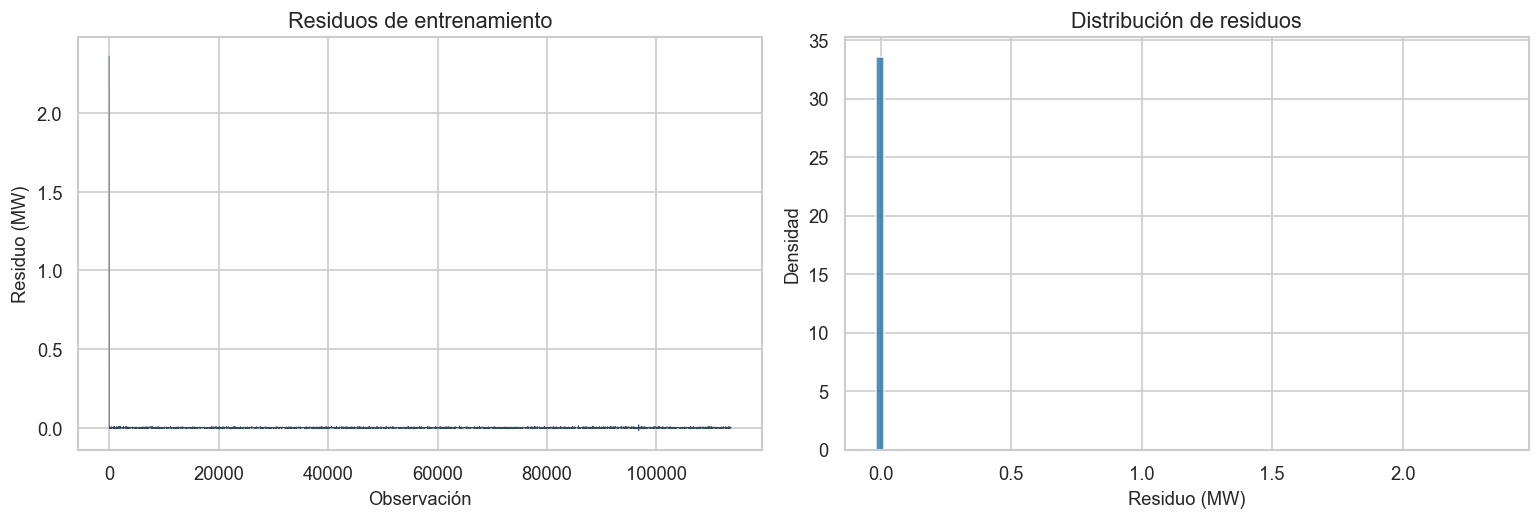

In [14]:
# ============================================================
# 13. PARÁMETROS, RESIDUOS Y LJUNG-BOX
# ============================================================

parameters = pd.DataFrame({
    "parameter": arimax_results.params.index,
    "coefficient": arimax_results.params.to_numpy(),
    "std_error": arimax_results.bse.to_numpy(),
    "p_value": arimax_results.pvalues.to_numpy(),
})
parameters["significant_005"] = parameters["p_value"] < 0.05
display(parameters)

residuals = pd.Series(np.asarray(arimax_results.resid, dtype=float)).replace([np.inf, -np.inf], np.nan).dropna()
residuals_for_test = residuals.iloc[-min(30_000, len(residuals)):]
ljung_box = (
    acorr_ljungbox(residuals_for_test, lags=[4, 20, 40, 120], return_df=True)
    .rename_axis("lag")
    .reset_index()
)
display(ljung_box)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(residuals.to_numpy(), linewidth=0.4, color="#34495E")
axes[0].set(title="Residuos de entrenamiento", xlabel="Observación", ylabel="Residuo (MW)")
axes[1].hist(residuals, bins=80, density=True, color="#2874A6", alpha=0.8)
axes[1].set(title="Distribución de residuos", xlabel="Residuo (MW)", ylabel="Densidad")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_residuos.png", bbox_inches="tight")
plt.show()


## 6. Evaluación *rolling origin*

Para cada origen se generan `HORIZON` predicciones y un intervalo central del 80 %. Después se incorporan las observaciones realmente ocurridas mediante `extend`, que actualiza el estado filtrado sin modificar los parámetros estimados. El avance entre orígenes está controlado por `ROLLING_STRIDE`; con el valor predeterminado, las trayectorias son no solapadas.


In [15]:
# ============================================================
# 14. FUNCIONES DE ACTUALIZACIÓN Y PRONÓSTICO RODANTE
# ============================================================

def extender_hasta(fitted_results, start_position):
    current = fitted_results
    if start_position > TRAIN_LEN:
        current = current.extend(
            endog=y_all.iloc[TRAIN_LEN:start_position],
            exog=X_all_scaled.iloc[TRAIN_LEN:start_position],
        )
    return current

def rolling_eval_arimax(fitted_results, dataset_name, start_position, end_position):
    current = extender_hasta(fitted_results, start_position)
    origins = construir_origenes(start_position, end_position)
    assert len(origins) == numero_esperado_origenes(start_position, end_position) > 0

    rows, inference_times = [], []

    for forecast_id, origin in enumerate(origins):
        forecast_index = df.index[origin:origin + HORIZON]
        last_exog = X_all_scaled.iloc[origin - 1].to_numpy(dtype=float)[None, :]
        exog_future = pd.DataFrame(
            np.repeat(last_exog, HORIZON, axis=0),
            index=forecast_index,
            columns=EXOG_COLS,
        )

        start_inference = time.time()
        forecast = current.get_forecast(steps=HORIZON, exog=exog_future)
        inference_times.append(time.time() - start_inference)
        predicted = np.asarray(forecast.predicted_mean, dtype=float).reshape(-1)
        interval = forecast.conf_int(alpha=INTERVAL_ALPHA)
        p10 = np.asarray(interval.iloc[:, 0], dtype=float).reshape(-1)
        p90 = np.asarray(interval.iloc[:, 1], dtype=float).reshape(-1)
        actual = y_all.iloc[origin:origin + HORIZON].to_numpy(dtype=float)
        persistence = float(y_all.iloc[origin - 1])
        lead_steps = np.arange(1, HORIZON + 1)

        rows.append(pd.DataFrame({
            "dataset": dataset_name,
            "forecast_id": forecast_id,
            "forecast_origin": df.index[origin],
            "timestamp": forecast_index,
            "lead_step": lead_steps,
            "lead_min": lead_steps * MODEL_STEP_SECONDS / 60.0,
            "y_true": actual,
            "y_pred": predicted,
            "y_pred_p10": p10,
            "y_pred_p90": p90,
            "y_persistence": persistence,
        }))

        update_end = min(origin + ROLLING_STRIDE, end_position)
        current = current.extend(
            endog=y_all.iloc[origin:update_end],
            exog=X_all_scaled.iloc[origin:update_end],
        )
        if (forecast_id + 1) % 50 == 0:
            print(f"{dataset_name}: {forecast_id + 1}/{len(origins)} trayectorias")

    result = pd.concat(rows, ignore_index=True)
    expected_rows = len(origins) * HORIZON
    assert len(result) == expected_rows
    assert result["forecast_id"].nunique() == len(origins)
    assert result.groupby("forecast_id").size().eq(HORIZON).all()
    assert np.isfinite(result[["y_true", "y_pred", "y_pred_p10", "y_pred_p90"]].to_numpy()).all()
    assert (result["y_pred_p10"] <= result["y_pred_p90"]).all()
    return result, np.asarray(inference_times, dtype=float)


In [16]:
# ============================================================
# 15. VALIDACIÓN Y PRUEBA
# ============================================================

eval_val, inference_val = rolling_eval_arimax(
    arimax_results, "VALIDATION", VAL_START, VAL_END
)
eval_test, inference_test = rolling_eval_arimax(
    arimax_results, "TEST", TEST_START, TEST_END
)

assert eval_val["forecast_id"].nunique() == len(val_origins)
assert eval_test["forecast_id"].nunique() == len(test_origins)
assert len(eval_val) == len(val_origins) * HORIZON
assert len(eval_test) == len(test_origins) * HORIZON

print(f"Inferencia media validation: {inference_val.mean():.4f} s/trayectoria")
print(f"Inferencia media test: {inference_test.mean():.4f} s/trayectoria")
display(eval_test.head())


VALIDATION: 50/288 trayectorias
VALIDATION: 100/288 trayectorias
VALIDATION: 150/288 trayectorias
VALIDATION: 200/288 trayectorias
VALIDATION: 250/288 trayectorias
TEST: 50/288 trayectorias
TEST: 100/288 trayectorias
TEST: 150/288 trayectorias
TEST: 200/288 trayectorias
TEST: 250/288 trayectorias
Inferencia media validation: 0.0048 s/trayectoria
Inferencia media test: 0.0052 s/trayectoria


,dataset,forecast_id,forecast_origin,timestamp,lead_step,lead_min,y_true,y_pred,y_pred_p10,y_pred_p90,y_persistence
0,TEST,0,2026-08-24 08:13:15,2026-08-24 08:13:15,1,0.250000,2.348270,2.348114,2.347016,2.349213,2.348210
1,TEST,0,2026-08-24 08:13:15,2026-08-24 08:13:30,2,0.500000,2.348500,2.348032,2.346300,2.349763,2.348210
2,TEST,0,2026-08-24 08:13:15,2026-08-24 08:13:45,3,0.750000,2.348729,2.347946,2.345806,2.350085,2.348210
3,TEST,0,2026-08-24 08:13:15,2026-08-24 08:14:00,4,1.000000,2.348959,2.347861,2.345372,2.350349,2.348210
4,TEST,0,2026-08-24 08:13:15,2026-08-24 08:14:15,5,1.250000,2.349189,2.347776,2.344985,2.350566,2.348210


In [17]:
# ============================================================
# 16. MÉTRICAS DETERMINÍSTICAS E INTERVALOS
# ============================================================

def metricas_basicas(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    error = y_true - y_pred
    mape_mask = np.abs(y_true) > 1e-9
    return {
        "MAE": float(np.mean(np.abs(error))),
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "MAPE_pct": float(np.mean(np.abs(error[mape_mask] / y_true[mape_mask])) * 100) if mape_mask.any() else np.nan,
        "R2": float(r2_score(y_true, y_pred)),
    }

def pinball_loss(y_true, y_pred, quantile):
    error = np.asarray(y_true) - np.asarray(y_pred)
    return float(np.mean(np.maximum(quantile * error, (quantile - 1) * error)))

def tabla_global(eval_df):
    rows = []
    for model_name, column in (("ARIMAX", "y_pred"), ("Persistencia", "y_persistence")):
        rows.append({"dataset": eval_df["dataset"].iloc[0], "modelo": model_name, **metricas_basicas(eval_df["y_true"], eval_df[column])})
    return pd.DataFrame(rows)

def tabla_intervalos(eval_df):
    return pd.DataFrame([{
        "dataset": eval_df["dataset"].iloc[0], "model": "ARIMAX_Gaussian_80pct",
        "nominal_coverage": 0.80,
        "empirical_coverage": float(np.mean((eval_df["y_true"] >= eval_df["y_pred_p10"]) & (eval_df["y_true"] <= eval_df["y_pred_p90"]))),
        "mean_width_MW": float(np.mean(eval_df["y_pred_p90"] - eval_df["y_pred_p10"])),
        "pinball_P10": pinball_loss(eval_df["y_true"], eval_df["y_pred_p10"], 0.10),
        "pinball_P90": pinball_loss(eval_df["y_true"], eval_df["y_pred_p90"], 0.90),
    }])

metrics_global = pd.concat([tabla_global(eval_val), tabla_global(eval_test)], ignore_index=True)
interval_metrics = pd.concat([tabla_intervalos(eval_val), tabla_intervalos(eval_test)], ignore_index=True)
display(metrics_global)
display(interval_metrics)


,dataset,modelo,MAE,RMSE,MAPE_pct,R2
0,VALIDATION,ARIMAX,0.005337,0.010417,0.231076,0.842574
1,VALIDATION,Persistencia,0.004935,0.010557,0.213299,0.838342
2,TEST,ARIMAX,0.005337,0.007901,0.232805,0.885277
3,TEST,Persistencia,0.004978,0.007862,0.216878,0.886402


,dataset,model,nominal_coverage,empirical_coverage,mean_width_MW,pinball_P10,pinball_P90
0,VALIDATION,ARIMAX_Gaussian_80pct,0.800000,0.748264,0.012699,0.001034,0.001840
1,TEST,ARIMAX_Gaussian_80pct,0.800000,0.705613,0.012699,0.001216,0.001399


In [18]:
# ============================================================
# 17. MÉTRICAS POR HORIZONTE Y EN EL HORIZONTE FINAL
# ============================================================

def tabla_por_horizonte(eval_df):
    rows = []
    for lead_step, subset in eval_df.groupby("lead_step", sort=True):
        ma = metricas_basicas(subset["y_true"], subset["y_pred"])
        mp = metricas_basicas(subset["y_true"], subset["y_persistence"])
        rows.append({
            "dataset": subset["dataset"].iloc[0],
            "lead_step": int(lead_step),
            "lead_min": float(subset["lead_min"].iloc[0]),
            **{f"{key}_ARIMAX": value for key, value in ma.items()},
            **{f"{key}_PERSISTENCIA": value for key, value in mp.items()},
            "MEJORA_MAE_pct": 100 * (mp["MAE"] - ma["MAE"]) / mp["MAE"] if mp["MAE"] > 0 else np.nan,
        })
    return pd.DataFrame(rows)

metrics_by_horizon = pd.concat([
    tabla_por_horizonte(eval_val),
    tabla_por_horizonte(eval_test),
], ignore_index=True)

metrics_horizon_final = metrics_by_horizon.loc[
    metrics_by_horizon["lead_step"].eq(HORIZON)
].copy()

assert len(metrics_horizon_final) == 2
assert np.allclose(metrics_horizon_final["lead_min"], HORIZON_MINUTES)

print(f"Métricas exactamente al horizonte final: {HORIZON_MINUTES:g} min")
display(metrics_horizon_final)


Métricas exactamente al horizonte final: 15 min


,dataset,lead_step,lead_min,MAE_ARIMAX,RMSE_ARIMAX,MAPE_pct_ARIMAX,R2_ARIMAX,MAE_PERSISTENCIA,RMSE_PERSISTENCIA,MAPE_pct_PERSISTENCIA,R2_PERSISTENCIA,MEJORA_MAE_pct
59,VALIDATION,60,15.000000,0.008614,0.013576,0.373713,0.722594,0.007636,0.013924,0.330407,0.708179,-12.808536
119,TEST,60,15.000000,0.009158,0.011994,0.399655,0.734568,0.008361,0.011904,0.364150,0.738536,-9.535538


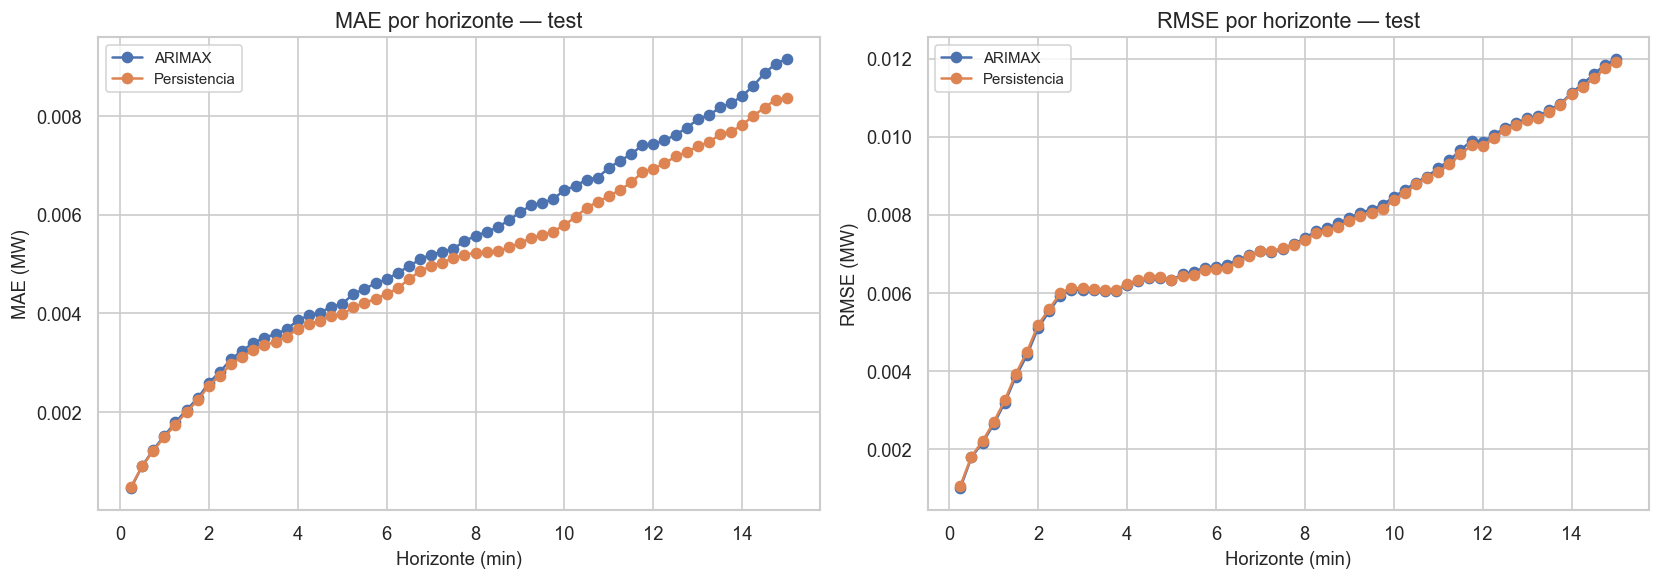

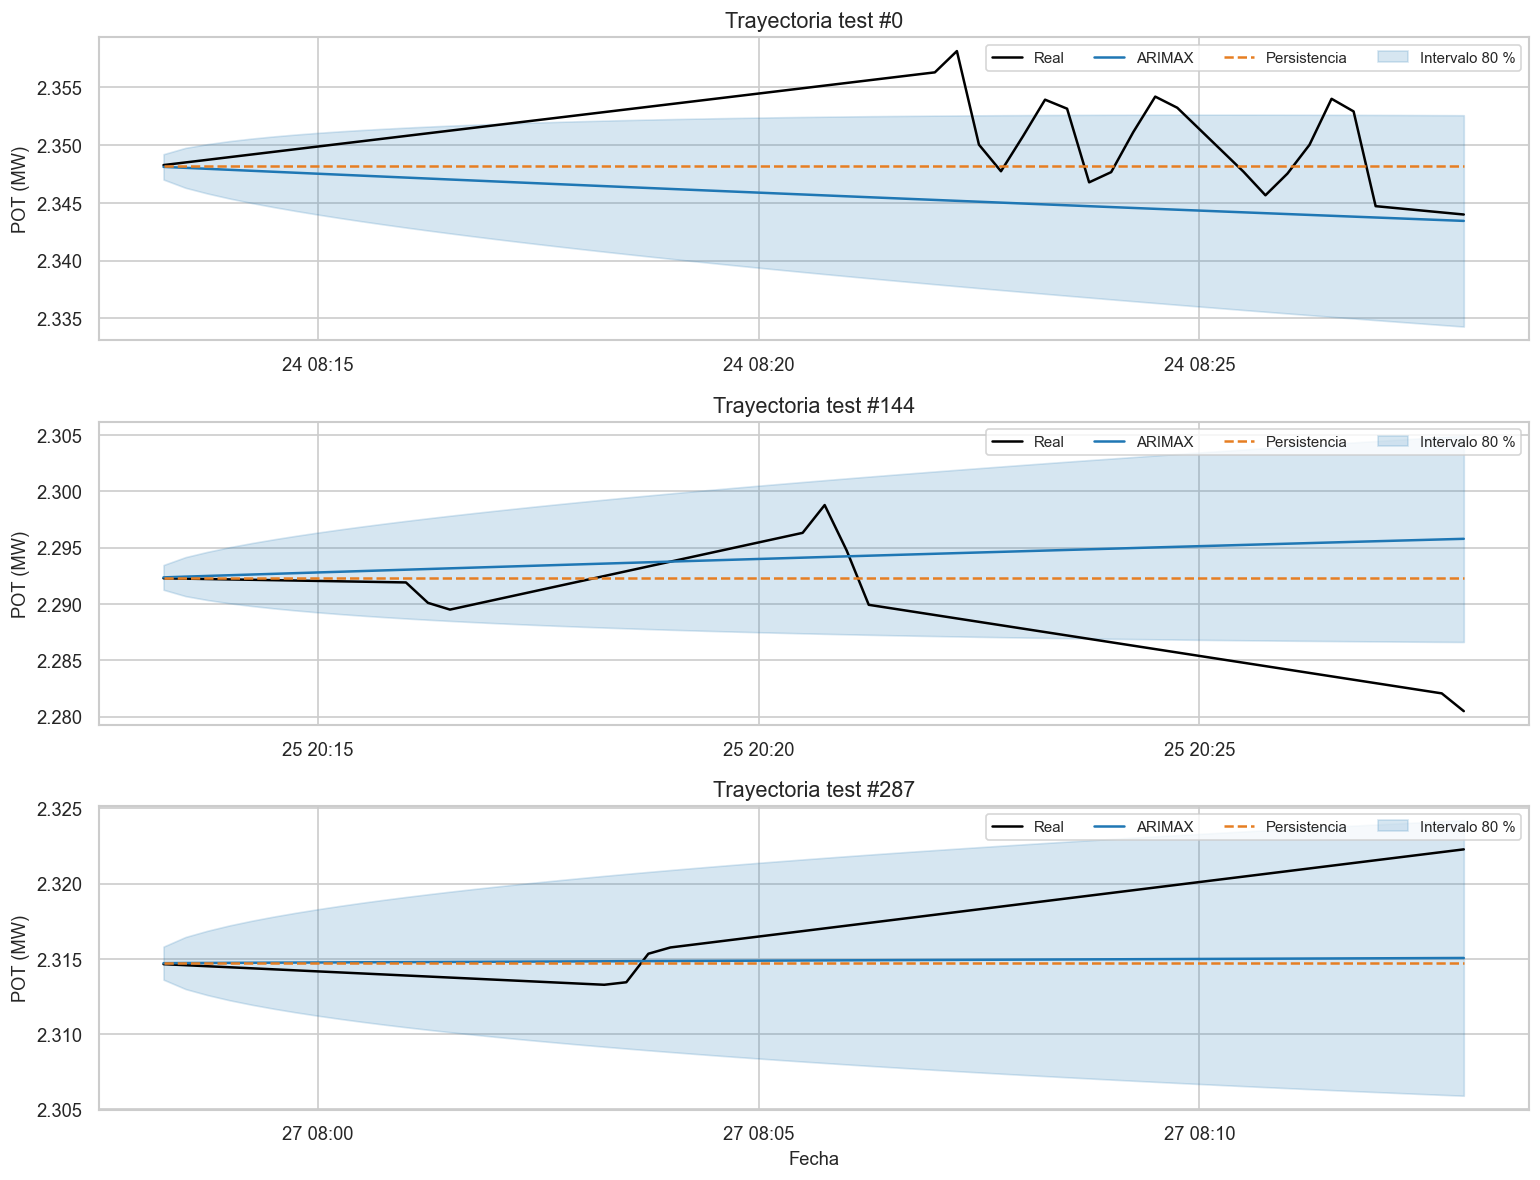

In [19]:
# ============================================================
# 18. CURVAS DE ERROR Y TRAYECTORIAS REPRESENTATIVAS
# ============================================================

test_h = metrics_by_horizon.query("dataset == 'TEST'")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(test_h["lead_min"], test_h["MAE_ARIMAX"], marker="o", label="ARIMAX")
axes[0].plot(test_h["lead_min"], test_h["MAE_PERSISTENCIA"], marker="o", label="Persistencia")
axes[0].set(xlabel="Horizonte (min)", ylabel="MAE (MW)", title="MAE por horizonte — test")
axes[0].legend()
axes[1].plot(test_h["lead_min"], test_h["RMSE_ARIMAX"], marker="o", label="ARIMAX")
axes[1].plot(test_h["lead_min"], test_h["RMSE_PERSISTENCIA"], marker="o", label="Persistencia")
axes[1].set(xlabel="Horizonte (min)", ylabel="RMSE (MW)", title="RMSE por horizonte — test")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_error_por_horizonte_test.png", bbox_inches="tight")
plt.show()

representative_ids = [0, len(test_origins) // 2, len(test_origins) - 1]
fig, axes = plt.subplots(3, 1, figsize=(13, 10))
for axis, forecast_id in zip(axes, representative_ids):
    sub = eval_test.query("forecast_id == @forecast_id")
    axis.plot(sub["timestamp"], sub["y_true"], label="Real", color="black")
    axis.plot(sub["timestamp"], sub["y_pred"], label="ARIMAX", color="#1F77B4")
    axis.plot(sub["timestamp"], sub["y_persistence"], label="Persistencia", linestyle="--", color="#E67E22")
    axis.fill_between(
        sub["timestamp"].to_numpy(), sub["y_pred_p10"].to_numpy(dtype=float),
        sub["y_pred_p90"].to_numpy(dtype=float), alpha=0.18, color="#1F77B4",
        label="Intervalo 80 %",
    )
    axis.set(title=f"Trayectoria test #{forecast_id}", ylabel="POT (MW)")
    axis.legend(ncol=4)
axes[-1].set_xlabel("Fecha")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_trayectorias_test.png", bbox_inches="tight")
plt.show()


## 7. Robustez, eventos e interpretación de exógenas

El *bootstrap* se realiza por trayectoria completa para mantener la dependencia interna entre los pasos del horizonte configurado. El evento secundario se define como `POT < 2.28 MW`, en concordancia con el análisis conservador P10 del TFT. El umbral debe confirmarse con planta antes de formular conclusiones operativas.


In [20]:
# ============================================================
# 19. BOOTSTRAP PAREADO POR TRAYECTORIA
# ============================================================

path_errors = eval_test.assign(
    abs_arimax=lambda d: np.abs(d["y_true"] - d["y_pred"]),
    abs_persistence=lambda d: np.abs(d["y_true"] - d["y_persistence"]),
).groupby("forecast_id")[["abs_arimax", "abs_persistence"]].mean()

rng = np.random.default_rng(SEED)
differences = np.empty(BOOTSTRAP_REPETITIONS, dtype=float)
path_values = path_errors.to_numpy()
for iteration in range(BOOTSTRAP_REPETITIONS):
    sampled = path_values[rng.integers(0, len(path_values), size=len(path_values))]
    differences[iteration] = np.mean(sampled[:, 1] - sampled[:, 0])

bootstrap_summary = pd.DataFrame([{
    "comparison": "MAE_persistencia - MAE_ARIMAX",
    "mean_difference_MW": float(differences.mean()),
    "ci95_low_MW": float(np.quantile(differences, 0.025)),
    "ci95_high_MW": float(np.quantile(differences, 0.975)),
    "probability_arimax_better": float(np.mean(differences > 0)),
    "bootstrap_unit": f"forecast_path_{HORIZON}_steps_{HORIZON_TAG}",
    "forecast_paths": int(len(path_values)),
    "repetitions": BOOTSTRAP_REPETITIONS,
}])
display(bootstrap_summary)


,comparison,mean_difference_MW,ci95_low_MW,ci95_high_MW,probability_arimax_better,bootstrap_unit,forecast_paths,repetitions
0,MAE_persistencia - MAE_ARIMAX,-0.000355,-0.000562,-0.000136,0.002000,forecast_path_60_steps_15min,288,2000


In [21]:
# ============================================================
# 20. EVENTOS BAJO EL UMBRAL OPERATIVO
# ============================================================

def event_metrics(y_true, y_score, threshold):
    actual = np.asarray(y_true) < threshold
    predicted = np.asarray(y_score) < threshold
    precision, recall, f1, _ = precision_recall_fscore_support(
        actual, predicted, average="binary", zero_division=0
    )
    tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[False, True]).ravel()
    return {
        "threshold_MW": threshold, "direction": "POT < threshold",
        "n_events_real": int(actual.sum()), "precision": precision,
        "recall": recall, "F1": f1, "TN": int(tn), "FP": int(fp),
        "FN": int(fn), "TP": int(tp),
    }

event_summary = pd.DataFrame([
    {"modelo": "ARIMAX_P50", **event_metrics(eval_test["y_true"], eval_test["y_pred"], POWER_DANGER_THRESHOLD)},
    {"modelo": "ARIMAX_P10", **event_metrics(eval_test["y_true"], eval_test["y_pred_p10"], POWER_DANGER_THRESHOLD)},
    {"modelo": "Persistencia", **event_metrics(eval_test["y_true"], eval_test["y_persistence"], POWER_DANGER_THRESHOLD)},
])
display(event_summary)


,modelo,threshold_MW,direction,n_events_real,precision,recall,F1,TN,FP,FN,TP
0,ARIMAX_P50,2.280000,POT < threshold,5905,0.876532,0.654022,0.749103,10831,544,2043,3862
1,ARIMAX_P10,2.280000,POT < threshold,5905,0.764256,0.948688,0.846543,9647,1728,303,5602
2,Persistencia,2.280000,POT < threshold,5905,0.841582,0.846571,0.844069,10434,941,906,4999


,parameter,coefficient,std_error,p_value,significant_005,absolute_coefficient,normalized_absolute_coefficient
1,F80,-0.000853,0.000110,0.000000,True,0.000853,0.517632
3,AA,0.000563,0.000022,0.000000,True,0.000563,0.341604
4,AD,0.000129,0.000024,0.000000,True,0.000129,0.078354
2,T,-0.000103,0.000050,0.041046,True,0.000103,0.062411


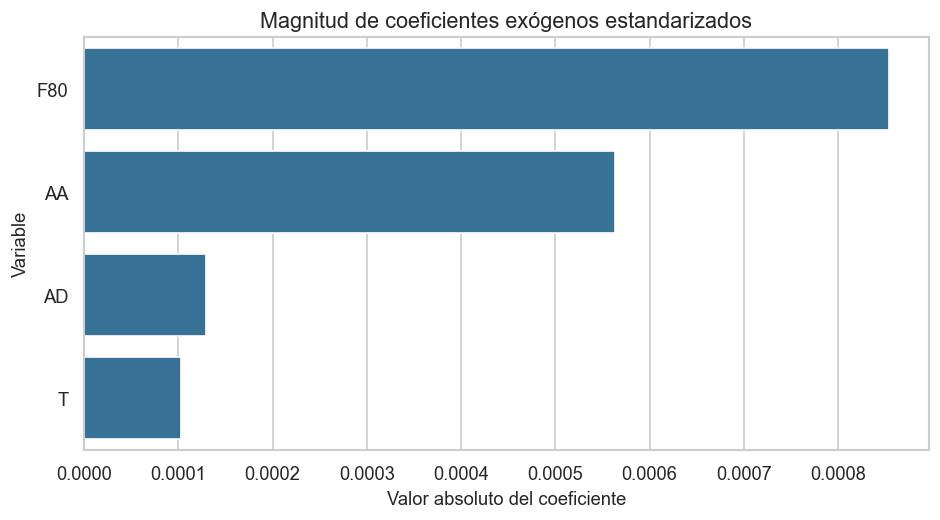

In [22]:
# ============================================================
# 21. COEFICIENTES EXÓGENOS ESTANDARIZADOS
# ============================================================

exog_coefficients = parameters.loc[parameters["parameter"].isin(EXOG_COLS)].copy()
exog_coefficients["absolute_coefficient"] = exog_coefficients["coefficient"].abs()
total_abs = exog_coefficients["absolute_coefficient"].sum()
exog_coefficients["normalized_absolute_coefficient"] = (
    exog_coefficients["absolute_coefficient"] / total_abs if total_abs > 0 else np.nan
)
exog_coefficients = exog_coefficients.sort_values("absolute_coefficient", ascending=False)
display(exog_coefficients)

fig, axis = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=exog_coefficients, x="absolute_coefficient", y="parameter", color="#2874A6", ax=axis)
axis.set(
    title="Magnitud de coeficientes exógenos estandarizados",
    xlabel="Valor absoluto del coeficiente", ylabel="Variable",
)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_coeficientes_exogenos.png", bbox_inches="tight")
plt.show()


## 8. Exportación reproducible

Se guardan el resultado ajustado de `statsmodels`, el escalador, las predicciones completas, métricas, diagnósticos, figuras, versiones y configuración. La carpeta resultante debe conservarse junto con el notebook ejecutado para redactar resultados, discusión y conclusiones.


In [23]:
# ============================================================
# 22. GUARDADO DE MODELO, TABLAS Y METADATOS
# ============================================================

arimax_results.save(MODEL_DIR / "modelo_arimax.pkl")
joblib.dump(scaler_exog, MODEL_DIR / "scaler_exogenas.joblib")

inference_summary = pd.DataFrame([
    {"dataset": "VALIDATION", "n_forecasts": len(inference_val), "mean_seconds": inference_val.mean(), "total_seconds": inference_val.sum()},
    {"dataset": "TEST", "n_forecasts": len(inference_test), "mean_seconds": inference_test.mean(), "total_seconds": inference_test.sum()},
])
tables = {
    "dataset_audit.csv": pd.DataFrame([dataset_audit]),
    "split_table.csv": split_table,
    "origin_summary.csv": origin_summary,
    "adf_results.csv": adf_table,
    "order_selection.csv": order_selection,
    "parameters.csv": parameters,
    "exogenous_coefficients.csv": exog_coefficients,
    "ljung_box.csv": ljung_box,
    "predictions_validation_long.csv": eval_val,
    "predictions_test_long.csv": eval_test,
    "metrics_global.csv": metrics_global,
    "metrics_by_horizon.csv": metrics_by_horizon,
    "metrics_horizon_final.csv": metrics_horizon_final,
    "interval_metrics.csv": interval_metrics,
    "bootstrap_summary.csv": bootstrap_summary,
    "event_summary.csv": event_summary,
    "inference_summary.csv": inference_summary,
}
for filename, table in tables.items():
    table.to_csv(TABLE_DIR / filename, index=False)

experiment_config = {
    "model": "ARIMAX via statsmodels SARIMAX",
    "dataset_sha256": DATASET_SHA256,
    "seed": SEED,
    "target": TARGET,
    "exogenous_columns": EXOG_COLS,
    "frequency": MODEL_FREQ,
    "model_step_seconds": MODEL_STEP_SECONDS,
    "common_context_steps": WINDOW,
    "common_context_minutes": WINDOW_MINUTES,
    "horizon_steps": HORIZON,
    "horizon_minutes": HORIZON_MINUTES,
    "rolling_stride": ROLLING_STRIDE,
    "rolling_stride_minutes": ROLLING_STRIDE_MINUTES,
    "selected_order": SELECTED_ORDER,
    "seasonal_order": SEASONAL_ORDER,
    "trend": TREND,
    "exogenous_future_strategy": EXOG_FUTURE_STRATEGY,
    "interval_alpha": INTERVAL_ALPHA,
    "AIC": float(arimax_results.aic),
    "BIC": float(arimax_results.bic),
    "converged": final_converged,
    "training_seconds": training_seconds,
    "validation_origins": len(val_origins),
    "test_origins": len(test_origins),
    "validation_evaluated_points": len(eval_val),
    "test_evaluated_points": len(eval_test),
}
environment = {
    "python": sys.version,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "statsmodels": statsmodels.__version__,
    "sklearn": __import__("sklearn").__version__,
    "joblib": joblib.__version__,
}
with open(ARTIFACT_DIR / "experiment_config.json", "w", encoding="utf-8") as stream:
    json.dump(experiment_config, stream, indent=2, ensure_ascii=False, default=str)
with open(ARTIFACT_DIR / "environment.json", "w", encoding="utf-8") as stream:
    json.dump(environment, stream, indent=2, ensure_ascii=False)

manifest_rows = []
for path in sorted(ARTIFACT_DIR.rglob("*")):
    if path.is_file() and path.name != "manifest.csv":
        manifest_rows.append({
            "relative_path": str(path.relative_to(ARTIFACT_DIR)),
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        })
manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(ARTIFACT_DIR / "manifest.csv", index=False)
print(f"Artefactos guardados en: {ARTIFACT_DIR.resolve()}")
display(manifest)


Artefactos guardados en: C:\Users\jgomeze\Documents\woody\Py\resultados_arimax_15min_final


,relative_path,bytes,sha256
0,environment.json,248,264aa3053c7d2f733e43d3398ed4d6f16516c5dc460329...
1,experiment_config.json,980,d80326d7df31c6ad3a6e51e73b081ca88c4b8b7e980b7b...
2,figuras\01_series_temporales.png,835701,ed1e5eb8e8e548736a8c65deeb8278567cee5514e3b813...
3,figuras\02_residuos.png,143123,392f36c3d24c5a697db1a3e6e8b9b23fd185636f082ae1...
4,figuras\03_error_por_horizonte_test.png,266442,bb2c949b48047ef2a86e6ca1f6dbfdc98de25183756ce5...
5,figuras\04_trayectorias_test.png,498734,0294c1b68f034dda170733067829a0934feefbe69c4a4c...
6,figuras\05_coeficientes_exogenos.png,81924,b48d76e0ec3c2c0666bdee952cb6c8ed587f6b3f506391...
7,final_summary.json,1208,ebec34163d20bb45bb93577388debac7b8a570d89203e8...
8,modelo\modelo_arimax.pkl,311189603,f2e7d24116ed7a1526ac11f9646e137acd46612eaf336a...
9,modelo\scaler_exogenas.joblib,1031,a2b44c95bdc6db403037a1c754066ddae203a2b1268d71...


In [24]:
# ============================================================
# 23. RESUMEN FINAL PARA LA REDACCIÓN DEL TFM
# ============================================================

global_test = metrics_global.query("dataset == 'TEST'").set_index("modelo")
final_horizon_test = metrics_horizon_final.query("dataset == 'TEST'").iloc[0]
test_interval = interval_metrics.query("dataset == 'TEST'").iloc[0]

final_summary = {
    "dataset_sha256": DATASET_SHA256,
    "selected_order": SELECTED_ORDER,
    "horizon_steps": HORIZON,
    "horizon_minutes": HORIZON_MINUTES,
    "rolling_stride_steps": ROLLING_STRIDE,
    "validation_forecast_paths": len(val_origins),
    "test_forecast_paths": len(test_origins),
    "test_MAE_ARIMAX_MW": float(global_test.loc["ARIMAX", "MAE"]),
    "test_RMSE_ARIMAX_MW": float(global_test.loc["ARIMAX", "RMSE"]),
    "test_MAPE_ARIMAX_pct": float(global_test.loc["ARIMAX", "MAPE_pct"]),
    "test_R2_ARIMAX": float(global_test.loc["ARIMAX", "R2"]),
    "test_MAE_persistence_MW": float(global_test.loc["Persistencia", "MAE"]),
    "final_horizon_MAE_ARIMAX_MW": float(final_horizon_test["MAE_ARIMAX"]),
    "final_horizon_RMSE_ARIMAX_MW": float(final_horizon_test["RMSE_ARIMAX"]),
    "final_horizon_R2_ARIMAX": float(final_horizon_test["R2_ARIMAX"]),
    "final_horizon_MAE_persistence_MW": float(final_horizon_test["MAE_PERSISTENCIA"]),
    "final_horizon_RMSE_persistence_MW": float(final_horizon_test["RMSE_PERSISTENCIA"]),
    "test_interval_coverage": float(test_interval["empirical_coverage"]),
    "test_interval_mean_width_MW": float(test_interval["mean_width_MW"]),
    "bootstrap_ci95_MW": [
        float(bootstrap_summary.loc[0, "ci95_low_MW"]),
        float(bootstrap_summary.loc[0, "ci95_high_MW"]),
    ],
    "training_seconds": training_seconds,
    "mean_test_inference_seconds_per_path": float(inference_test.mean()),
    "exogenous_future_strategy": EXOG_FUTURE_STRATEGY,
}
with open(ARTIFACT_DIR / "final_summary.json", "w", encoding="utf-8") as stream:
    json.dump(final_summary, stream, indent=2, ensure_ascii=False, default=str)

print(json.dumps(final_summary, indent=2, ensure_ascii=False, default=str))
print(
    f"\nCORRIDA FINALIZADA PARA {HORIZON_MINUTES:g} MIN. "
    f"Comprima {ARTIFACT_DIR.name} y consérvela junto al notebook ejecutado."
)


{
  "dataset_sha256": "13ab2cc37de733a14a352a7cd8c7b1b681499e4b8470d360205a5e75b84a7cf1",
  "selected_order": [
    3,
    0,
    1
  ],
  "horizon_steps": 60,
  "horizon_minutes": 15.0,
  "rolling_stride_steps": 60,
  "validation_forecast_paths": 288,
  "test_forecast_paths": 288,
  "test_MAE_ARIMAX_MW": 0.005337188978065478,
  "test_RMSE_ARIMAX_MW": 0.007900917865045905,
  "test_MAPE_ARIMAX_pct": 0.23280478987664013,
  "test_R2_ARIMAX": 0.8852773262707994,
  "test_MAE_persistence_MW": 0.004978413504726074,
  "final_horizon_MAE_ARIMAX_MW": 0.009158270721300245,
  "final_horizon_RMSE_ARIMAX_MW": 0.011993823456781282,
  "final_horizon_R2_ARIMAX": 0.7345681325763022,
  "final_horizon_MAE_persistence_MW": 0.008361004009259253,
  "final_horizon_RMSE_persistence_MW": 0.01190384250206278,
  "test_interval_coverage": 0.7056134259259259,
  "test_interval_mean_width_MW": 0.012699392399496474,
  "bootstrap_ci95_MW": [
    -0.0005616284284347714,
    -0.00013640656752957804
  ],
  "training_secon

## 9. Criterios de interpretación y limitaciones

1. **Exógenas futuras.** Los valores se mantienen constantes durante el horizonte configurado. El resultado depende de la razonabilidad operacional de este supuesto.
2. **Estado frente a ventana fija.** ARIMAX utiliza un estado filtrado y retardos seleccionados, no las entradas explícitas de XGBoost/TFT. Esta diferencia arquitectónica debe declararse.
3. **Generalización temporal.** El test representa los últimos tres días y no garantiza estabilidad ante cambios de mineral, mantenimiento o deriva.
4. **Persistencia.** En una señal de alta inercia es una referencia exigente. Un modelo que no la supere aporta igualmente un resultado científico válido.
5. **Intervalos.** La cobertura depende de los supuestos gaussianos y de la correcta especificación del modelo.
6. **Coeficientes.** Expresan asociación condicional con variables estandarizadas; no prueban causalidad metalúrgica.
7. **Umbral.** `2.28 MW` debe confirmarse y documentarse como criterio oficial antes de formular conclusiones operativas.
8. **Cobertura temporal.** Si la longitud de una partición no es múltiplo exacto de `ROLLING_STRIDE`, puede quedar una cola sin evaluar; `origin_summary.csv` registra la cobertura efectiva.

### Referencias metodológicas

- Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time Series Analysis: Forecasting and Control* (5th ed.). Wiley.
- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.
- Durbin, J., & Koopman, S. J. (2012). *Time Series Analysis by State Space Methods* (2nd ed.). Oxford University Press.
- Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*, 92–96.
